Testing the transformer model for bitcoin to check performance

In [1]:
from transformer_model import TransformerModel, predict_model

In [3]:
import torch
import numpy as np
import random
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [4]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [5]:
btc_df_tr = pd.read_csv(
    r'feature_datasets\BTC_features.csv',
    parse_dates=True,
    index_col=0
)

In [6]:
btc_y_tr = btc_df_tr['Close'].shift(-1)
btc_X_tr = btc_df_tr.drop(columns=['Close'])

In [7]:
# Drop last row because shifted y has NaN there
btc_X_tr = btc_X_tr.iloc[:-1]
btc_y_tr = btc_y_tr.iloc[:-1]

# Convert y to numpy
btc_y_tr = btc_y_tr.values

# Check shapes
print("BTC X shape:", btc_X_tr.shape)
print("BTC y shape:", btc_y_tr.shape)

BTC X shape: (915, 29)
BTC y shape: (915,)


In [9]:
btc_X_train_tr, btc_X_test_tr, btc_y_train_tr, btc_y_test_tr = train_test_split(
    btc_X_tr,
    btc_y_tr,
    test_size=0.3,
    shuffle=False
)

print("BTC X_train shape:", btc_X_train_tr.shape)
print("BTC X_test shape:", btc_X_test_tr.shape)
print("BTC y_train shape:", btc_y_train_tr.shape)
print("BTC y_test shape:", btc_y_test_tr.shape)

BTC X_train shape: (640, 29)
BTC X_test shape: (275, 29)
BTC y_train shape: (640,)
BTC y_test shape: (275,)


In [10]:
btc_test_dates_tr = btc_X_test_tr.index

In [11]:
x_scaler_tr = MinMaxScaler()

btc_X_train_scaled_tr = x_scaler_tr.fit_transform(btc_X_train_tr)
btc_X_test_scaled_tr = x_scaler_tr.transform(btc_X_test_tr)

print("Scaled X_train shape:", btc_X_train_scaled_tr.shape)
print("Scaled X_test shape:", btc_X_test_scaled_tr.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [12]:
y_scaler_tr = MinMaxScaler()

btc_y_train_scaled_tr = y_scaler_tr.fit_transform(
    btc_y_train_tr.reshape(-1, 1)
).flatten()

btc_y_test_scaled_tr = y_scaler_tr.transform(
    btc_y_test_tr.reshape(-1, 1)
).flatten()

In [13]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

btc_X_train_seq_tr, btc_y_train_seq_tr = create_sequences(
    btc_X_train_scaled_tr,
    btc_y_train_scaled_tr,
    time_steps=30
)

btc_X_test_seq_tr, btc_y_test_seq_tr = create_sequences(
    btc_X_test_scaled_tr,
    btc_y_test_scaled_tr,
    time_steps=30
)

print("BTC X_train_seq shape:", btc_X_train_seq_tr.shape)
print("BTC y_train_seq shape:", btc_y_train_seq_tr.shape)
print("BTC X_test_seq shape:", btc_X_test_seq_tr.shape)
print("BTC y_test_seq shape:", btc_y_test_seq_tr.shape)


BTC X_train_seq shape: (610, 30, 29)
BTC y_train_seq shape: (610,)
BTC X_test_seq shape: (245, 30, 29)
BTC y_test_seq shape: (245,)


## Transformer model training

In [14]:
input_size_tr = btc_X_train_seq_tr.shape[2]

model_TR = TransformerModel(
    input_size=input_size_tr,
    d_model=64,
    nhead=4,
    num_layers=2,
    output_size=1
)

print(model_TR)

TransformerModel(
  (input_projection): Linear(in_features=29, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [17]:
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_TR = model_TR.to(device)

In [24]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_TR.parameters(), lr=0.001)

In [25]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset_tr = TensorDataset(
    torch.tensor(btc_X_train_seq_tr, dtype=torch.float32),
    torch.tensor(btc_y_train_seq_tr, dtype=torch.float32)
)

train_loader_tr = DataLoader(
    train_dataset_tr,
    batch_size=32,
    shuffle=False
)

In [26]:
import pandas as pd

epochs = 50
epoch_losses_tr = []

model_TR.train()
for epoch in range(epochs):
    running_loss = 0.0

    for xb, yb in train_loader_tr:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model_TR(xb)
        loss = criterion(outputs.squeeze(), yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader_tr)
    epoch_losses_tr.append([epoch + 1, avg_loss])

loss_df_TR = pd.DataFrame(epoch_losses_tr, columns=["Epoch", "Loss"])

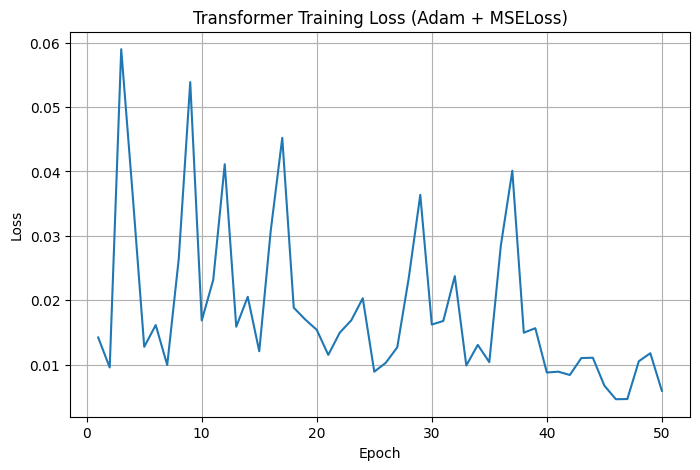

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_df_TR["Epoch"], loss_df_TR["Loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training Loss (Adam + MSELoss)")
plt.grid(True)
plt.show()

In [29]:
btc_preds_TR = predict_model(model_TR, btc_X_test_seq_tr)

print("Predictions shape:", btc_preds_TR.shape)
print("First 10 predictions:", btc_preds_TR[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.33455765]
 [0.32240662]
 [0.3325031 ]
 [0.3315559 ]
 [0.34203777]
 [0.34098583]
 [0.3499096 ]
 [0.34748107]
 [0.3331988 ]
 [0.3666458 ]]


In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
btc_preds_TR_actual = y_scaler_tr.inverse_transform(btc_preds_TR.reshape(-1, 1))

# Skip first 30 because of 30-day sequence
btc_y_test_actual_tr = btc_y_test_tr[30:].reshape(-1, 1)

# Calculate metrics
mse_TR = mean_squared_error(btc_y_test_actual_tr, btc_preds_TR_actual)
rmse_TR = np.sqrt(mse_TR)
mae_TR = mean_absolute_error(btc_y_test_actual_tr, btc_preds_TR_actual)
r2_TR = r2_score(btc_y_test_actual_tr, btc_preds_TR_actual)
mape_TR = np.mean(np.abs((btc_y_test_actual_tr - btc_preds_TR_actual) / btc_y_test_actual_tr)) * 100

print("Transformer Results:")
print(f"MSE: {mse_TR:.2f}")
print(f"RMSE: {rmse_TR:.2f}")
print(f"MAE: {mae_TR:.2f}")
print(f"R2 Score: {r2_TR:.4f}")
print(f"MAPE: {mape_TR:.2f}%")

Transformer Results:
MSE: 51757226.41
RMSE: 7194.25
MAE: 6792.97
R2 Score: -0.6799
MAPE: 22.89%
